In [1]:
import gymnasium as gym
import numpy as np
import random
import matplotlib.pyplot as plt


In [2]:
# SETTINGS

episode_list = [500, 1000, 2000, 5000, 10000]

learning_rate = 0.8
discount_factor = 0.95

epsilon_start = 1.0
epsilon_min = 0.01
epsilon_decay = 0.995

max_steps = 100
test_episodes = 100

results = {}


In [3]:
# TRAINING FUNCTION

def train_q_learning(number_of_episodes):

    env = gym.make("FrozenLake-v1", is_slippery=True)

    states = env.observation_space.n
    actions = env.action_space.n

    Q = np.zeros((states, actions))

    epsilon = epsilon_start

    episode_rewards = []

    for episode in range(number_of_episodes):

        state, info = env.reset()
        total_reward = 0

        for step in range(max_steps):

            # Epsilon-greedy action selection
            if random.random() < epsilon:
                action = env.action_space.sample()
            else:
                action = np.argmax(Q[state])

            # Take action
            new_state, reward, terminated, truncated, info = env.step(action)

            done = terminated or truncated

            # Q-learning update
            if done:
                target = reward
            else:
                target = reward + discount_factor * np.max(Q[new_state])

            Q[state, action] = Q[state, action] + learning_rate * (
                target - Q[state, action]
            )

            state = new_state
            total_reward += reward

            if done:
                break

        # Store reward
        episode_rewards.append(total_reward)

        # Decrease epsilon
        epsilon = max(epsilon_min, epsilon * epsilon_decay)

    env.close()

    return Q, episode_rewards


In [4]:
# TESTING FUNCTION

def test_agent(Q):

    env = gym.make("FrozenLake-v1", is_slippery=True)

    successful_episodes = 0

    for episode in range(test_episodes):

        state, info = env.reset()
        done = False

        while not done:

            # No exploration during testing
            action = np.argmax(Q[state])

            state, reward, terminated, truncated, info = env.step(action)

            done = terminated or truncated

        if reward == 1:
            successful_episodes += 1

    success_rate = (successful_episodes / test_episodes) * 100

    env.close()

    return success_rate


In [5]:
# TRAIN ALL CONFIGURATIONS

for episodes in episode_list:

    print("\nTraining with", episodes, "episodes...")

    Q_table, rewards = train_q_learning(episodes)

    success_rate = test_agent(Q_table)

    results[episodes] = {
        "Q": Q_table,
        "rewards": rewards,
        "success_rate": success_rate
    }

    print("Success Rate:", round(success_rate, 2), "%")



Training with 500 episodes...
Success Rate: 33.0 %

Training with 1000 episodes...
Success Rate: 62.0 %

Training with 2000 episodes...
Success Rate: 0.0 %

Training with 5000 episodes...
Success Rate: 75.0 %

Training with 10000 episodes...
Success Rate: 63.0 %


In [7]:
# DISPLAY RESULTS

print("FINAL RESULTS")

for episodes in episode_list:

    rewards = results[episodes]["rewards"]
    success = results[episodes]["success_rate"]

    print(
        episodes,
        "episodes -> Success Rate:",
        round(success, 2),
        "%"
    )



FINAL RESULTS
500 episodes -> Success Rate: 0.0 %
1000 episodes -> Success Rate: 79.0 %
2000 episodes -> Success Rate: 58.0 %
5000 episodes -> Success Rate: 33.0 %
10000 episodes -> Success Rate: 60.0 %


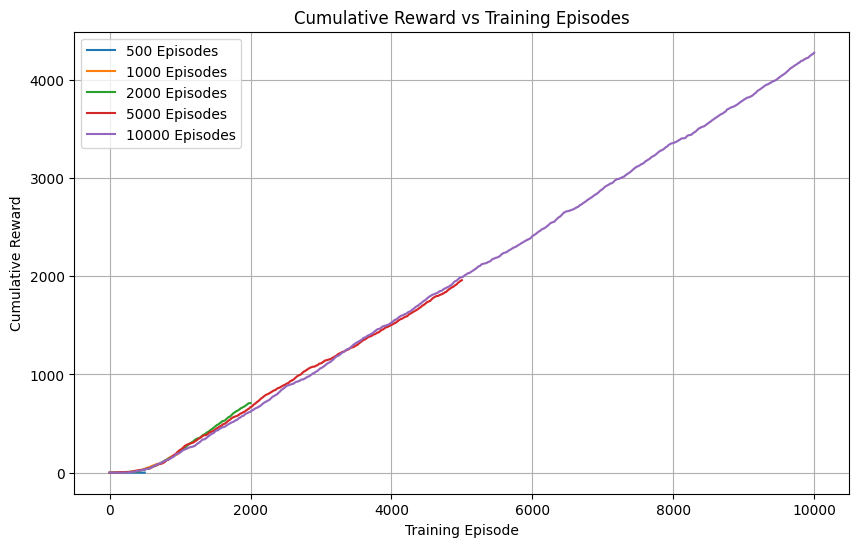

In [8]:
# 1. CUMULATIVE REWARD PLOT

plt.figure(figsize=(10, 6))

for episodes in episode_list:

    rewards = results[episodes]["rewards"]

    cumulative_reward = np.cumsum(rewards)

    plt.plot(
        cumulative_reward,
        label=str(episodes) + " Episodes"
    )

plt.xlabel("Training Episode")
plt.ylabel("Cumulative Reward")
plt.title("Cumulative Reward vs Training Episodes")
plt.legend()
plt.grid()
plt.show()


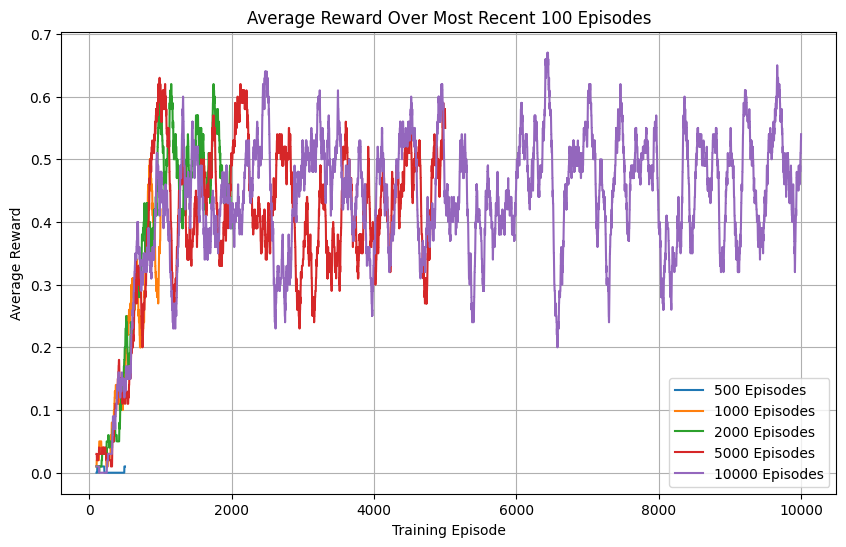

In [9]:
# 2. AVERAGE REWARD OF LAST 100 EPISODES

plt.figure(figsize=(10, 6))

for episodes in episode_list:

    rewards = results[episodes]["rewards"]

    if len(rewards) >= 100:
        average_reward = np.convolve(
            rewards,
            np.ones(100) / 100,
            mode="valid"
        )

        plt.plot(
            np.arange(100, len(rewards) + 1),
            average_reward,
            label=str(episodes) + " Episodes"
        )

plt.xlabel("Training Episode")
plt.ylabel("Average Reward")
plt.title("Average Reward Over Most Recent 100 Episodes")
plt.legend()
plt.grid()
plt.show()


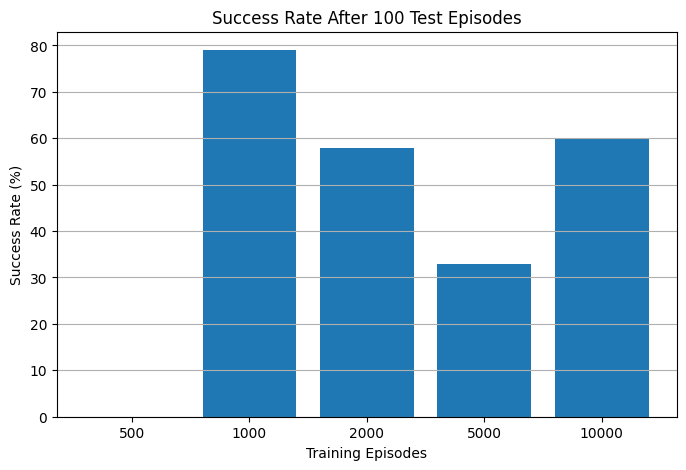

In [10]:
# 3. SUCCESS RATE COMPARISON

episodes = list(results.keys())
success_rates = [
    results[x]["success_rate"] for x in episodes
]

plt.figure(figsize=(8, 5))

plt.bar(
    [str(x) for x in episodes],
    success_rates
)

plt.xlabel("Training Episodes")
plt.ylabel("Success Rate (%)")
plt.title("Success Rate After 100 Test Episodes")
plt.grid(axis="y")
plt.show()

In [11]:
# 4. EXTRACT LEARNED POLICY

best_episodes = 10000

Q_table = results[best_episodes]["Q"]

policy = np.argmax(Q_table, axis=1)

print("\nLearned Policy:")
print(policy)




Learned Policy:
[0 3 1 1 0 0 2 0 3 1 1 0 0 2 1 0]


In [12]:
# 5. VISUALIZE EXTRACTED POLICY

action_symbols = {
    0: "←",
    1: "↓",
    2: "→",
    3: "↑"
}

lake_map = [
    "SFFF",
    "FHFH",
    "FFFH",
    "HFFG"
]

print("\nExtracted Policy:\n")

for state in range(16):

    row = state // 4
    column = state % 4

    if lake_map[row][column] == "H":
        symbol = "H"

    elif lake_map[row][column] == "G":
        symbol = "G"

    else:
        symbol = action_symbols[policy[state]]

    print(f"{symbol:^5}", end="")

    if column == 3:
        print()



Extracted Policy:

  ←    ↑    ↓    ↓  
  ←    H    →    H  
  ↑    ↓    ↓    H  
  H    →    ↓    G  


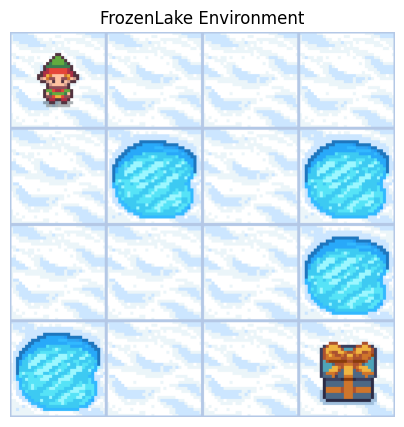

In [6]:
# 6. VISUALIZE ENVIRONMENT

env = gym.make(
    "FrozenLake-v1",
    is_slippery=True,
    render_mode="rgb_array"
)

state, info = env.reset()

image = env.render()

plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.axis("off")
plt.title("FrozenLake Environment")
plt.show()

env.close()